In [ ]:
# 실습 라이브러리(lib) 준비 — 교재 저장소에서 자동으로 받아옵니다 (Google Drive 불필요)
import os, sys
path = "/content/"
if not os.path.isdir(path + "lib"):
    !git clone -q --depth 1 https://github.com/AI-BoostCamp/ReinforcementLearning.git /content/_rl && cp -r /content/_rl/code/lib /content/lib && rm -rf /content/_rl
sys.path.append(path + "lib")
os.makedirs(path + "models/DRL", exist_ok=True)   # 학습된 모델 저장 위치 (세션 종료 시 사라짐)


In [2]:
from variable_print import p,ps,pst

In [3]:
import gym
import tensorflow as tf
import keras
from keras import layers
import numpy as np
import random
from collections import deque

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3]
plt.rcParams["font.size"] = "8"
import warnings
warnings.filterwarnings("ignore")

/usr/local/lib/python3.10/dist-packages/tensorflow/lite/python/util.py:55: DeprecationWarning: jax.xla_computation is deprecated. Please use the AOT APIs; see https://jax.readthedocs.io/en/latest/aot.html. For example, replace xla_computation(f)(*xs) with jit(f).lower(*xs).compiler_ir('hlo'). See CHANGELOG.md for 0.4.30 for more examples.
  from jax import xla_computation as _xla_computation


In [4]:
%%capture
!pip install swig
!pip install gym[box2d]

# LunarLander_Continuous Environment

In [5]:

problem = "LunarLanderContinuous-v2"
env = gym.make(problem,new_step_api=True)

num_states = env.observation_space.shape[0]      # 8
num_actions = env.action_space.shape[0] # 2

state = env.reset()
p(state,'state') #(8,)

<<state>>:
Shape:(8,)
Type: <class 'numpy.ndarray'>
Values: [-0.00378771  1.408695   -0.38366574 -0.09890141  0.00439577  0.0869059
  0.          0.        ]


# Replay Buffer

In [6]:
class RBuffer():
  def __init__(self, maxsize, statedim, naction):
    self.cnt = 0
    self.maxsize = maxsize
    self.state_memory = np.zeros((maxsize, statedim), dtype=np.float32)
    self.action_memory = np.zeros((maxsize, naction), dtype=np.float32)
    self.reward_memory = np.zeros((maxsize,), dtype=np.float32)
    self.next_state_memory = np.zeros((maxsize, statedim), dtype=np.float32)
    self.not_done_memory = np.zeros((maxsize,), dtype=bool)

  def record(self, state, action, reward, next_state, done):
    index = self.cnt % self.maxsize
    self.state_memory[index] = state
    self.action_memory[index] = action
    self.reward_memory[index] = reward
    self.next_state_memory[index] = next_state
    self.not_done_memory[index] = 1 - done
    self.cnt += 1

  def get_batch(self, batch_size):
    max_mem = min(self.cnt, self.maxsize)
    batch = np.random.choice(max_mem, batch_size, replace= False)
    states = tf.convert_to_tensor(self.state_memory[batch], dtype= tf.float32)
    actions = tf.convert_to_tensor(self.action_memory[batch], dtype= tf.float32)
    rewards = tf.convert_to_tensor(self.reward_memory[batch], dtype= tf.float32)
    next_states = tf.convert_to_tensor(self.next_state_memory[batch], dtype= tf.float32)
    not_dones = tf.convert_to_tensor(self.not_done_memory[batch], dtype= tf.float32)
    return states, actions, rewards, next_states, not_dones

# TD3

## Actor-Network, Critic-Network

In [ ]:
nodes = 256 #512

class Critic(tf.keras.Model):
  def __init__(self):
    super(Critic, self).__init__()
    self.f1 = layers.Dense(nodes, activation='relu')
    self.f2 = layers.Dense(nodes, activation='relu')
    self.v =  layers.Dense(1, activation='linear')

  def call(self, inputs):
    inputstate, inputaction = inputs
    x = self.f1(tf.concat([inputstate, inputaction], axis=1))
    x = self.f2(x)
    x = self.v(x)
    return x

class Actor(tf.keras.Model):
  def __init__(self):
    super(Actor, self).__init__()
    self.f1 = layers.Dense(nodes, activation='relu')
    self.f2 = layers.Dense(nodes, activation='relu')
    self.mu = layers.Dense(num_actions, activation='tanh')

  def call(self, state):
    x = self.f1(state)
    x = self.f2(x)
    x = self.mu(x)
    return x

## TD3 Agent

In [ ]:
class TD3Agent():
  def __init__(self, env, n_RBuffer, batch_size=64):
    self.memory = RBuffer(n_RBuffer, num_states, num_actions)
    self.actor_main = Actor()
    self.actor_target = Actor()
    self.critic_main = Critic()
    self.critic_main2 = Critic()
    self.critic_target = Critic()
    self.critic_target2 = Critic()
    # Network Copy
    self.update_target(self.actor_target.weights, self.actor_main.weights, 1.0)
    self.update_target(self.critic_target.weights, self.critic_main.weights, 1.0)
    self.update_target(self.critic_target2.weights, self.critic_main2.weights, 1.0)

    ### Hyper Parameters ###
    self.batch_size = batch_size
    self.actor_update_steps = 2
    self.warmup = 2000 #1000  #(Iterations)
    self.gamma = 0.99
    self.tau = 0.02 #0.005
    self.expl_noise = 0.1 #0.1
    self.warmup_noise = 1.0

    self.a_lr = 0.001 #0.001
    self.c_lr = 0.002 #0.002
    # Network Optimization definition
    self.a_opt = tf.keras.optimizers.Adam(self.a_lr)
    self.c_opt1 = tf.keras.optimizers.Adam(self.c_lr)
    self.c_opt2 = tf.keras.optimizers.Adam(self.c_lr)

    # Action space
    self.n_actions = len(env.action_space.high) # 2
    self.min_action = env.action_space.low[0]   # -1.0
    self.max_action = env.action_space.high[0]  # 1.0

    self.train_step = 0 # Iterations
    self.loss_q = 0
    self.loss_a = 0
    self.losses = []
    self.a_n_rate = 0

  ## Soft Update
  @tf.function
  def update_target(self, target_weights, weights, tau):
      for (a, b) in zip(target_weights, weights):
          a.assign(b * tau + a * (1 - tau))

  ## Get Action
  def get_action(self, state, get ='main'):
      if get == 'main' :  # get actor_main(call from maim loop)
          action = self.actor_main(state)
          if self.train_step < self.warmup : # warmup mode
              noise = tf.random.normal(shape=[self.n_actions], mean=0.0, stddev=self.warmup_noise)
          else:
              noise = tf.random.normal(shape=[self.n_actions], mean=0.0, stddev=self.expl_noise)
      else :              # get actor_target(call form train loop)
          action = self.actor_target(state)
          noise = tf.random.normal(shape=[self.n_actions], mean=0.0, stddev=self.expl_noise)
          noise = tf.clip_by_value(noise, -0.5, 0.5)
      action = tf.clip_by_value(action+noise, -1, 1)
      self.a_n_rate = self.a_n_rate * 0.9 + 0.1 * tf.reduce_mean(noise**2)/tf.reduce_mean(action**2)
      return action

  def train(self):
      if self.memory.cnt < self.batch_size: return
      states, actions, rewards, next_states, not_dones = self.memory.get_batch(self.batch_size)
      next_actions = self.get_action(next_states, get='target') # from actor_target
      ## CriticMain Network Update
      self.loss_q = self.train_step_critic(states, actions, rewards, next_states, not_dones, next_actions)
      self.train_step += 1
      ## ActorMain Net. Update & Actor/Critic Target Net. Update
      if self.train_step % self.actor_update_steps == 0:
          self.loss_a = self.train_step_actor(states)
          ## ActorTarget update
          self.update_target(self.actor_target.weights, self.actor_main.weights, self.tau)
          ## CriticTarget update
          self.update_target(self.critic_target.weights, self.critic_main.weights, self.tau)
          self.update_target(self.critic_target2.weights, self.critic_main2.weights, self.tau)
      self.losses.append([self.loss_a,self.loss_q])

  @tf.function
  def train_step_critic(self, states, actions, rewards, next_states, not_dones, next_actions):
      with tf.GradientTape() as tape1, tf.GradientTape() as tape2:
          target_q1 = tf.squeeze(self.critic_target([next_states, next_actions]), 1)
          target_q2 = tf.squeeze(self.critic_target2([next_states, next_actions]), 1)
          target_q =  tf.math.minimum(target_q1, target_q2)
          target_q = rewards + self.gamma * target_q * not_dones
          critic_value = tf.squeeze(self.critic_main([states, actions]), 1)
          critic_value2 = tf.squeeze(self.critic_main2([states, actions]), 1)
          loss_q1 = tf.keras.losses.MSE(target_q, critic_value)
          loss_q2 = tf.keras.losses.MSE(target_q, critic_value2)
      grads1 = tape1.gradient(loss_q1, self.critic_main.trainable_variables)
      grads2 = tape2.gradient(loss_q2, self.critic_main2.trainable_variables)
      self.c_opt1.apply_gradients(zip(grads1, self.critic_main.trainable_variables))
      self.c_opt2.apply_gradients(zip(grads2, self.critic_main2.trainable_variables))
      return  loss_q1+loss_q2

  @tf.function
  def train_step_actor(self, states):
      with tf.GradientTape() as tape:
          new_policy_actions = self.actor_main(states)
          loss_a = -self.critic_main([states, new_policy_actions])
          loss_a = tf.math.reduce_mean(loss_a)
      grads = tape.gradient(loss_a, self.actor_main.trainable_variables)
      self.a_opt.apply_gradients(zip(grads, self.actor_main.trainable_variables))
      return loss_a

## Training

In [ ]:
def ma_loss(n=10): # average loss
    if len(agent.losses) <n : return 0,0
    a = np.array(agent.losses[-1])[0]
    q = np.array(agent.losses[-n:])[:,1]
    q_ret = np.cumsum(q, dtype=np.float32)
    return a, q_ret[-1] / n

In [ ]:
%%time
# Hyper Parameters
batch_size = 256 #64 #128 256
n_RBuffer = 20000 #5000 #10000 20000

episods = 150 #500
total_avgr_best = 50 #150
step_limit = 600 #800 2000

ep_reward = []
total_avgr = []
steps = []

problem = "LunarLanderContinuous-v2"
env = gym.make(problem,new_step_api=True)

agent = TD3Agent(env, n_RBuffer, batch_size=batch_size)

for s in range(episods):
  episodic_reward = 0
  state = env.reset()
  done = False
  step_cnt = 0
  while (not done) and (step_cnt < step_limit):
    state = tf.convert_to_tensor([state], dtype=tf.float32)
    action = agent.get_action(state, get ='main')[0] # from actor_main
    next_state, reward, done, truncated, info = env.step(action)
    agent.memory.record(state, action, reward, next_state, done)
    agent.train() ###
    state = next_state
    episodic_reward += reward
    step_cnt += 1
  ep_reward.append(episodic_reward)
  avg_reward = np.mean(ep_reward[-5:])
  total_avgr.append(avg_reward)
  steps.append(step_cnt)
  loss_a, loss_q = ma_loss()
  print(f'Epis(steps):{s:03d}({step_cnt:04d}), reward:{episodic_reward:.2f}, avg reward:{avg_reward:.2f}',end="")
  print(f', RB.cnt:{agent.memory.cnt}, Cnt_limit:{step_limit:02d}, BatchSize:{agent.batch_size}',end="")
  print(f' Loss(a,q):{loss_a:.1f}, {loss_q:.1f}, noise/action:{agent.a_n_rate:0.2f}')
  if total_avgr_best < avg_reward :
    total_avgr_best = avg_reward
    # Save the weights
    agent.actor_main.save(path+"/models/DRL/Lunar_Lander_TD3_2.keras")
    print(f'Model Saved.')
  if avg_reward > 60: break #150

agent.actor_main = keras.models.load_model(path+"/models/DRL/Lunar_Lander_TD3_2.keras")

## Evaluation

In [ ]:
losses = np.array(agent.losses)
def ma(a, n=25):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

In [ ]:
skips = int(len(losses)/len(ep_reward))
print(skips)
loss_a_sub = ma(losses[:,0])[::skips].copy()
loss_q_sub = ma(losses[:,1])[::skips].copy()
loss_tot = loss_q_sub + loss_a_sub
print(len(loss_tot),len(ep_reward))

173
100 100


hidden_nodes:256, n_RBuffer:20000, actor_update_steps:2, warmup:2000
tau:0.02,a_lr:0.001,c_lr:0.0005, Cnt_limit:600, BatchSize:256


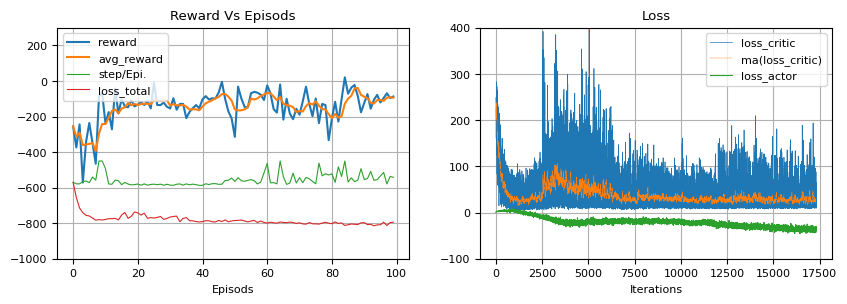

In [ ]:
print(f'hidden_nodes:{nodes}, n_RBuffer:{n_RBuffer}, actor_update_steps:{agent.actor_update_steps}, warmup:{agent.warmup}')
print(f'tau:{agent.tau},a_lr:{agent.a_lr},c_lr:{agent.c_lr}, Cnt_limit:{step_limit:02d}, BatchSize:{agent.batch_size}')

plt.figure(figsize=(10,3))
plt.subplot(121)

plt.plot(ep_reward,label='reward')
plt.plot(total_avgr,label='avg_reward')
plt.plot(np.array(steps)/4-600,label='step/Epi.',linewidth=0.8)
plt.plot(loss_tot-800,label='loss_total',linewidth=0.8)
plt.title("Reward Vs Episods")
plt.xlabel("Episods")
plt.ylim(-1000,300)
plt.grid()
plt.legend()

plt.subplot(122)
plt.plot(losses[:,1],label='loss_critic',linewidth=0.5)
plt.plot(ma(losses[:,1]),label='ma(loss_critic)',linewidth=0.3)
plt.plot(losses[:,0],label='loss_actor',linewidth=0.8)
plt.title("Loss")
plt.xlabel("Iterations")
plt.ylim(-100,400)
plt.grid()
plt.legend()
plt.show()

In [ ]:
total_reward = 0
state = env.reset()
done = False
cnt = 0
while not done:
    action = agent.actor_main(state.reshape(1,8))
    next_state, reward, done, info, _ = env.step(action[0])
    state = next_state
    total_reward += reward
    cnt += 1
    if done:
       print(f'cnt:{cnt},reward:{total_reward}')

cnt:307,reward:232.59963955182695


In [ ]:
%%capture
!pip install gym pyvirtualdisplay
!apt-get install -y python-opengl ffmpeg
!apt install chromium-browser xvfb

In [ ]:
from render import  show_video, wrap_env, render_as_image

In [ ]:
from pyvirtualdisplay import Display
display = Display(visible=0, size=(400, 300))
display.start()

In [ ]:
env = wrap_env(env, path=path, name_prefix="TD3-LundarLander")
state = env.reset()
cnt = 0
while True:
    render_as_image(env,step=cnt)
    action = agent.actor_main(state.reshape(1,8))
    state, reward, done, info = env.step(action[0])
    if done:  break;
    cnt += 1
env.close()

In [ ]:
show_video(path=path,name_prefix='TD3-LundarLander-episode-0')

# 실습과제 2 : Ablation study     
#### Delayed policy update  
#### * self.actor_update_steps = 2 수정      
#### Target policy smoothing  
#### * target_actions += tf.clip_by_value( target_noise, -0.5, 0.5 )  
#### Clipped Double Q-learning  
#### * Clitic Net. 1, 2 --> Single Clitic Net.  

# 실습과제 2 : 예시  
## TD3 - DP - TPS - CDQ = DDPQ style


In [ ]:
problem = "LunarLanderContinuous-v2"
env = gym.make(problem,new_step_api=True)

### Actor-Network, Critic-Network

In [7]:
nodes = 256 #128 #512
class Critic(tf.keras.Model):
  def __init__(self):
    super(Critic, self).__init__()
    self.f1 = layers.Dense(nodes, activation='relu')
    self.f2 = layers.Dense(nodes, activation='relu')
    self.v =  layers.Dense(1, activation=None)

  def call(self, inputs):
    inputstate, inputaction = inputs
    x = self.f1(tf.concat([inputstate, inputaction], axis=1))
    x = self.f2(x)
    x = self.v(x)
    return x

class Actor(tf.keras.Model):
  def __init__(self):
    super(Actor, self).__init__()
    self.f1 = layers.Dense(nodes, activation='relu')
    self.f2 = layers.Dense(nodes, activation='relu')
    self.mu = layers.Dense(num_actions, activation='tanh')

  def call(self, state):
    x = self.f1(state)
    x = self.f2(x)
    x = self.mu(x)
    return x

## TD3toDDPG Agent

In [24]:
class Agent():
  def __init__(self, env, n_RBuffer, batch_size=64):
    self.memory = RBuffer(n_RBuffer, num_states, num_actions)
    self.actor_main = Actor()
    self.actor_target = Actor()
    self.critic_main = Critic()
    self.critic_target = Critic()
    # Network Copy
    self.update_target(self.actor_target, self.actor_main, 1.0)
    self.update_target(self.critic_target, self.critic_main, 1.0)
#    self.update_target(self.critic_target2, self.critic_main2, 1.0)

## Clipped Double Q-learning
    # self.critic_main2 = Critic()
    # self.critic_target2 = Critic()
    # self.update_target(self.critic_target2.weights, self.critic_main2.weights, 1.0)
    # self.c_opt2 = tf.keras.optimizers.Adam(self.c_lr)

    self.a_lr = 0.001
    self.c_lr = 0.0005 #0.001 #0.002
    self.a_opt = tf.keras.optimizers.Adam(self.a_lr)
    self.c_opt1 = tf.keras.optimizers.Adam(self.c_lr)

    self.n_actions = len(env.action_space.high) # 2
    self.min_action = env.action_space.low[0]
    self.max_action = env.action_space.high[0]

    self.batch_size = batch_size
    self.warmup = 100 #200 #1000
    self.gamma = 0.99
    self.tau = 0.05 #0.005
    self.trainstep = 0 # No. of Iterations
    self.expl_noise = 0.1 #0.1
    self.warmup_noise = 1.0
## Delayed policy update
    self.actor_update_steps = 1 ####2#####

    self.train_step = 0 # Iterations
    self.loss_q = 0
    self.loss_a = 0
    self.losses = []
    self.a_n_rate = 0

  ## Get Action
  def get_action(self, state, get ='main'):
      if get == 'main' :  # get actor_main(call from maim loop)
          action = self.actor_main(state)
          if self.train_step < self.warmup : # warmup mode
              noise = tf.random.normal(shape=[self.n_actions], mean=0.0, stddev=self.warmup_noise)
          else:
              noise = tf.random.normal(shape=[self.n_actions], mean=0.0, stddev=self.expl_noise)
      else :              # get actor_target(call form train loop)
          action = self.actor_target(state)
## Target policy smoothing
          # noise = tf.random.normal(shape=[self.n_actions], mean=0.0, stddev=self.expl_noise)
          # noise = tf.clip_by_value(noise, -0.5, 0.5)
          noise = 0.
      action = tf.clip_by_value(action+noise, -1, 1)
      self.a_n_rate = self.a_n_rate * 0.9 + 0.1 * tf.reduce_mean(noise**2)/tf.reduce_mean(action**2)
      return action

  @tf.function
  def update_target(self,target_model, source_model, tau):
      for target_var, source_var in zip(target_model.trainable_variables,\
                                        source_model.trainable_variables):
          target_var.assign(tau * source_var + (1 - tau) * target_var)

  def train(self):
      if self.memory.cnt < self.batch_size: return
      states, actions, rewards, next_states, not_dones = self.memory.get_batch(self.batch_size)

      next_actions = self.get_action(next_states, get='target') # from actor_target
      ## CriticMain Network Update
      self.loss_q = self.train_step_critic(states, actions, rewards, next_states, not_dones, next_actions)
      self.train_step += 1
      ## ActorMain Net. Update & Actor/Critic Target Net. Update
      if self.train_step % self.actor_update_steps == 0:
          self.loss_a = self.train_step_actor(states)
          ## ActorTarget update
          self.update_target(self.actor_target, self.actor_main, self.tau)
          ## CriticTarget update
          self.update_target(self.critic_target, self.critic_main, self.tau)
#          self.update_target(self.critic_target2, self.critic_main2, self.tau)
      self.losses.append([self.loss_a,self.loss_q])

  @tf.function
  def train_step_critic(self, states, actions, rewards, next_states, not_dones, next_actions):
      with tf.GradientTape() as tape1, tf.GradientTape() as tape2:
## Clipped Double Q-learning
#          target_q1 = tf.squeeze(self.critic_target([next_states, next_actions]), 1)
#          target_q2 = tf.squeeze(self.critic_target2([next_states, next_actions]), 1)
#          target_q =  tf.math.minimum(target_q1, target_q2)
          target_q = tf.squeeze(self.critic_target([next_states, next_actions]), 1)
          target_q = rewards + self.gamma * target_q * not_dones
          critic_value = tf.squeeze(self.critic_main([states, actions]), 1)
          loss_q1 = tf.keras.losses.MSE(target_q, critic_value)
      grads1 = tape1.gradient(loss_q1, self.critic_main.trainable_variables)
      self.c_opt1.apply_gradients(zip(grads1, self.critic_main.trainable_variables))
## Clipped Double Q-learning
#          critic_value2 = tf.squeeze(self.critic_main2([states, actions]), 1)
#          loss_q2 = tf.keras.losses.MSE(target_q, critic_value2)
#      grads2 = tape2.gradient(loss_q2, self.critic_main2.trainable_variables)
#      self.c_opt2.apply_gradients(zip(grads2, self.critic_main2.trainable_variables))
      return  loss_q1

  @tf.function
  def train_step_actor(self, states):
      with tf.GradientTape() as tape:
          new_policy_actions = self.actor_main(states)
          loss_a = -self.critic_main([states, new_policy_actions])
          loss_a = tf.math.reduce_mean(loss_a)
      grads = tape.gradient(loss_a, self.actor_main.trainable_variables)
      self.a_opt.apply_gradients(zip(grads, self.actor_main.trainable_variables))
      return loss_a

## Training

In [25]:
def ma_loss(n=10): # average loss
    if len(agent.losses) <n : return 0,0
    a = np.array(agent.losses[-1])[0]
    q = np.array(agent.losses[-n:])[:,1]
    q_ret = np.cumsum(q, dtype=np.float32)
    return a, q_ret[-1] / n

In [26]:
%%time
# Hyper Parameters
batch_size = 256 #64 #128 256
n_RBuffer = 20000 #5000 #10000 20000

episods = 500 #100
total_avgr_best = 60
step_limit = 600 #800 2000

ep_reward = []
total_avgr = []
steps = []

problem = "LunarLanderContinuous-v2"
env = gym.make(problem,new_step_api=True)
agent = Agent(env, n_RBuffer, batch_size=batch_size)

for s in range(episods):
  episodic_reward = 0
  state = env.reset()
  done = False
  step_cnt = 0
  while (not done) and (step_cnt < step_limit):
    state = tf.convert_to_tensor([state], dtype=tf.float32)
    action = agent.get_action(state, get ='main')[0] # from actor_main
    next_state, reward, done, truncated, info = env.step(action)
    agent.memory.record(state, action, reward, next_state, done)
    agent.train() ###
    state = next_state
    episodic_reward += reward
    step_cnt += 1
  ep_reward.append(episodic_reward)
  avg_reward = np.mean(ep_reward[-10:])
  total_avgr.append(avg_reward)
  steps.append(step_cnt)
  loss_a, loss_q = ma_loss()
  print(f'Epis(steps):{s:03d}({step_cnt:04d}), reward:{episodic_reward:.2f}, avg reward:{avg_reward:.2f}',end="")
  print(f', RB.cnt:{agent.memory.cnt}, Cnt_limit:{step_limit:02d}, BatchSize:{agent.batch_size}',end="")
  print(f' Loss(a,q):{loss_a:.1f},{loss_q:.1f}, noise/action:{agent.a_n_rate:0.2f}')
  if total_avgr_best < avg_reward :
    total_avgr_best = avg_reward
    # Save the weights
    agent.actor_main.save(path+"/models/DRL/Lunar_Lander_TD3toDDPG.keras")
    print(f'Model Saved.')
  if avg_reward > 100: break #150

agent.actor_main = keras.models.load_model(path+"/models/DRL/Lunar_Lander_TD3toDDPG.keras")

Epis(steps):000(0088), reward:-385.66, avg reward:-385.66, RB.cnt:88, Cnt_limit:600, BatchSize:256 Loss(a,q):0.0,0.0, noise/action:1.82
Epis(steps):001(0143), reward:-145.83, avg reward:-265.75, RB.cnt:231, Cnt_limit:600, BatchSize:256 Loss(a,q):0.0,0.0, noise/action:1.34


Epis(steps):002(0234), reward:-542.30, avg reward:-357.93, RB.cnt:465, Cnt_limit:600, BatchSize:256 Loss(a,q):1.3,8.9, noise/action:0.00
Epis(steps):003(0151), reward:-807.24, avg reward:-470.26, RB.cnt:616, Cnt_limit:600, BatchSize:256 Loss(a,q):-7.8,11.2, noise/action:0.01
Epis(steps):004(0076), reward:-747.03, avg reward:-525.61, RB.cnt:692, Cnt_limit:600, BatchSize:256 Loss(a,q):-9.3,24.5, noise/action:0.00
Epis(steps):005(0067), reward:-533.37, avg reward:-526.91, RB.cnt:759, Cnt_limit:600, BatchSize:256 Loss(a,q):-4.3,16.9, noise/action:0.01
Epis(steps):006(0064), reward:-702.98, avg reward:-552.06, RB.cnt:823, Cnt_limit:600, BatchSize:256 Loss(a,q):3.6,20.2, noise/action:0.01
Epis(steps):007(0086), reward:-943.15, avg reward:-600.95, RB.cnt:909, Cnt_limit:600, BatchSize:256 Loss(a,q):25.4,44.2, noise/action:0.01
Epis(steps):008(0062), reward:-522.23, avg reward:-592.20, RB.cnt:971, Cnt_limit:600, BatchSize:256 Loss(a,q):40.8,71.1, noise/action:0.01
Epis(steps):009(0068), reward:

TypeError: Could not locate class 'Actor'. Make sure custom classes are decorated with `@keras.saving.register_keras_serializable()`. Full object config: {'module': None, 'class_name': 'Actor', 'config': {'trainable': True, 'dtype': {'module': 'keras', 'class_name': 'DTypePolicy', 'config': {'name': 'float32'}, 'registered_name': None}}, 'registered_name': 'Actor', 'build_config': {'input_shape': [1, 8]}}

## Evaluation  

In [27]:
def ma(a, n=25):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

In [28]:
losses = np.array(agent.losses)

In [29]:
skips = int(len(losses)/len(ep_reward))
print(skips)
loss_a_sub = ma(losses[:,0])[::skips].copy()
loss_q_sub = ma(losses[:,1])[::skips].copy()
loss_tot = loss_q_sub + loss_a_sub
print(len(loss_tot),len(ep_reward))

369
181 181


hidden_nodes:256, n_RBuffer:20000, actor_update_steps:1, warmup:100
tau:0.05,a_lr:0.001,c_lr:0.0005, Cnt_limit:600, BatchSize:256


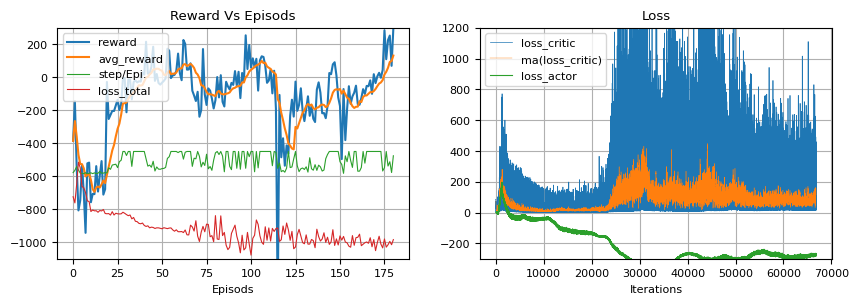

In [30]:
print(f'hidden_nodes:{nodes}, n_RBuffer:{n_RBuffer}, actor_update_steps:{agent.actor_update_steps}, warmup:{agent.warmup}')
print(f'tau:{agent.tau},a_lr:{agent.a_lr},c_lr:{agent.c_lr}, Cnt_limit:{step_limit:02d}, BatchSize:{agent.batch_size}')

plt.figure(figsize=(10,3))
plt.subplot(121)

plt.plot(ep_reward,label='reward')
plt.plot(total_avgr,label='avg_reward')
plt.plot(np.array(steps)/4-600,label='step/Epi.',linewidth=0.8)
plt.plot(loss_tot-800,label='loss_total',linewidth=0.8)
plt.title("Reward Vs Episods")
plt.xlabel("Episods")
plt.ylim(-1100,300)
plt.grid()
plt.legend()

plt.subplot(122)
plt.plot(losses[:,1],label='loss_critic',linewidth=0.5)
plt.plot(ma(losses[:,1]),label='ma(loss_critic)',linewidth=0.3)
plt.plot(losses[:,0],label='loss_actor',linewidth=0.8)
plt.title("Loss")
plt.xlabel("Iterations")
plt.ylim(-300,1200)
plt.grid()
plt.legend()
plt.show()